# RB weekly Silver facts

## tl;dr

This notebook creates `silver_rb_week` for the 2023–2025 contextual RB/FB population at one row per `player_id + season + week + team`. The output contains **5,826 rows and 62 columns** across three season partitions.

The play-level facts contribute 37,099 canonical rush attempts, 6,376 red-zone rush attempts, 1,897 goal-line rush attempts, and 9,692 targets. Targets and receiving air yards reconcile exactly with all 5,084 rows that have weekly-stat evidence. Canonical PBP rush attempts are one lower because Dare Ogunbowale's 2024 Week 15 run is credited in weekly stats while the source play remains labeled `no_play`; both observations remain visible.

The output also preserves 742 snap-only RB/FB rows with null weekly statistics and observed zero PBP opportunities. Calculated target share matches nflverse for all 5,084 comparable rows, and all declared grain, relationship, denominator, null-versus-zero, range, and Parquet round-trip checks pass.


## Context & Methods

### Scope

The shared Silver notebooks established canonical player-week records, standardized plays, and team-week opportunity denominators. The WR notebook proved the first position-specific pattern. This notebook reuses those foundations for running backs while making the rushing concepts more explicit.

Weekly player statistics remain nullable source evidence. Standardized PBP supplies observed player opportunities, including zeroes for RBs or FBs who appeared in a covered game without a carry or target. Team-week facts supply the denominators for transparent same-week shares.

### Key assumptions

- A contextual RB row has `RB` or `FB` in weekly stat or snap-position evidence. Master and roster positions enrich the shared table but do not determine eligibility here.
- `RB` and `FB` remain distinguishable in their source fields; the notebook does not overwrite position disagreements.
- Weekly stats remain authoritative for official rushing and receiving production. PBP counts remain separate and are reconciled before they become opportunity numerators.
- `rush_attempt_share` uses player non-kneel rushes divided by team non-kneel rushes. `designed_rush_share` further excludes QB scrambles from the team denominator.
- Receiving shares use the same definitions established for WR facts.
- A zero team denominator produces a null share. A valid denominator with no player opportunity produces a zero share.
- Every calculation is same-week. Combined opportunities, rolling features, fantasy points, rankings, and future-looking features remain outside this Silver dataset.


## Data

### 1. Set up paths, grains, and selected fields


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEASONS = [2023, 2024, 2025]
RB_POSITION_LABELS = {"RB", "FB"}
RB_WEEK_GRAIN = ["player_id", "season", "week", "team"]
PLAYER_GAME_TEAM_KEY = ["player_id", "game_id", "team"]
TEAM_WEEK_GRAIN = ["team", "season", "week"]

# Find the repository root whether this runs from Jupyter or nbconvert.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "ROADMAP.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "ROADMAP.md").exists():
            PROJECT_ROOT = parent
            break
    else:
        raise RuntimeError("Could not locate the repository root.")

BRONZE_DIR = PROJECT_ROOT / "data/bronze"
SILVER_DIR = PROJECT_ROOT / "data/silver"
PLAYER_WEEK_DIR = SILVER_DIR / "player_week"
STANDARDIZED_PLAYS_DIR = SILVER_DIR / "standardized_plays"
TEAM_WEEK_OPPORTUNITY_DIR = SILVER_DIR / "team_week_opportunity"
RB_WEEK_DIR = SILVER_DIR / "rb_week"

PLAYER_WEEK_COLUMNS = [
    "player_id",
    "game_id",
    "season",
    "week",
    "game_type",
    "season_type",
    "team",
    "opponent_team",
    "display_name",
    "stats_position",
    "snap_position",
    "has_stat_record",
    "has_snap_record",
    "participated_game",
    "offensive_participant",
    "offense_snaps",
    "offense_snap_pct",
    "rushing_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "receiving_targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
]

PBP_COLUMNS = [
    "game_id",
    "play_id",
    "team",
    "receiver_player_id",
    "rusher_player_id",
    "target_air_yards",
    "rushing_yards",
    "is_no_play",
    "source_rush_attempt",
    "is_target",
    "is_red_zone_target",
    "is_goal_line_target",
    "is_end_zone_target",
    "is_rush_attempt",
    "is_non_kneel_rush_attempt",
    "is_designed_rush_attempt",
    "is_red_zone_rush_attempt",
    "is_goal_line_rush_attempt",
]

TEAM_WEEK_COLUMNS = [
    "team",
    "season",
    "week",
    "game_id",
    "team_targets",
    "team_air_yards",
    "team_rush_attempts",
    "team_non_kneel_rush_attempts",
    "team_designed_rush_attempts",
    "team_red_zone_targets",
    "team_goal_line_targets",
    "team_end_zone_targets",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

BRONZE_VALIDATION_COLUMNS = [
    "player_id",
    "season",
    "week",
    "team",
    "targets",
    "receiving_air_yards",
    "passing_air_yards",
    "target_share",
    "air_yards_share",
]

pd.set_option("display.max_columns", 75)


### 2. Define the RB metric contract

The output keeps official weekly-stat production separate from PBP opportunity evidence. Rushing shares use non-kneel or designed team rushing totals so QB clock-management plays and scrambles do not distort an RB's role.


In [2]:
metric_contract = pd.DataFrame(
    [
        ["pbp_rush_attempts", "Canonical official rush attempts for the player", "standardized plays"],
        ["pbp_non_kneel_rush_attempts", "Canonical rush attempts excluding kneels", "standardized plays"],
        ["pbp_designed_rush_attempts", "Non-kneel rush attempts excluding QB scrambles", "standardized plays"],
        ["red_zone_rush_attempts", "Non-kneel rush attempts at yardline_100 <= 20", "standardized plays"],
        ["goal_line_rush_attempts", "Non-kneel rush attempts at yardline_100 <= 5", "standardized plays"],
        ["pbp_targets", "Canonical targets to the player", "standardized plays"],
        ["pbp_target_air_yards", "Air yards attached to canonical player targets", "standardized plays"],
        ["rush_attempt_share", "pbp_non_kneel_rush_attempts / team_non_kneel_rush_attempts", "same-week team denominator"],
        ["designed_rush_share", "pbp_designed_rush_attempts / team_designed_rush_attempts", "same-week team denominator"],
        ["red_zone_rush_share", "red_zone_rush_attempts / team_red_zone_rush_attempts", "same-week team denominator"],
        ["goal_line_rush_share", "goal_line_rush_attempts / team_goal_line_rush_attempts", "same-week team denominator"],
        ["target_share", "pbp_targets / team_targets", "same-week team denominator"],
    ],
    columns=["field", "definition", "source_or_denominator"],
)

metric_contract


,field,definition,source_or_denominator
0,pbp_rush_attempts,Canonical official rush attempts for the player,standardized plays
1,pbp_non_kneel_rush_attempts,Canonical rush attempts excluding kneels,standardized plays
2,pbp_designed_rush_attempts,Non-kneel rush attempts excluding QB scrambles,standardized plays
3,red_zone_rush_attempts,Non-kneel rush attempts at yardline_100 <= 20,standardized plays
4,goal_line_rush_attempts,Non-kneel rush attempts at yardline_100 <= 5,standardized plays
5,pbp_targets,Canonical targets to the player,standardized plays
6,pbp_target_air_yards,Air yards attached to canonical player targets,standardized plays
7,rush_attempt_share,pbp_non_kneel_rush_attempts / team_non_kneel_r...,same-week team denominator
8,designed_rush_share,pbp_designed_rush_attempts / team_designed_rus...,same-week team denominator
9,red_zone_rush_share,red_zone_rush_attempts / team_red_zone_rush_at...,same-week team denominator


### 3. Load the persisted inputs


In [3]:
player_week_paths = sorted(PLAYER_WEEK_DIR.glob("*.parquet"))
standardized_play_paths = sorted(STANDARDIZED_PLAYS_DIR.glob("*.parquet"))
team_week_paths = sorted(TEAM_WEEK_OPPORTUNITY_DIR.glob("*.parquet"))
bronze_stat_paths = sorted((BRONZE_DIR / "player_stats_weekly").glob("*.parquet"))

assert len(player_week_paths) == len(SEASONS)
assert len(standardized_play_paths) == len(SEASONS)
assert len(team_week_paths) == len(SEASONS)
assert len(bronze_stat_paths) == len(SEASONS)

player_week = pd.concat(
    [pd.read_parquet(path) for path in player_week_paths],
    ignore_index=True,
)
standardized_plays = pd.concat(
    [pd.read_parquet(path, columns=PBP_COLUMNS) for path in standardized_play_paths],
    ignore_index=True,
)
team_week_opportunity = pd.concat(
    [pd.read_parquet(path, columns=TEAM_WEEK_COLUMNS) for path in team_week_paths],
    ignore_index=True,
)
bronze_weekly_stats = pd.concat(
    [pd.read_parquet(path, columns=BRONZE_VALIDATION_COLUMNS) for path in bronze_stat_paths],
    ignore_index=True,
)

input_summary = pd.DataFrame(
    [
        ["Silver player_week", len(player_week), len(player_week.columns), len(PLAYER_WEEK_COLUMNS)],
        ["Silver standardized_plays", len(standardized_plays), 56, len(standardized_plays.columns)],
        ["Silver team_week_opportunity", len(team_week_opportunity), 24, len(team_week_opportunity.columns)],
        ["Bronze weekly stats (validation only)", len(bronze_weekly_stats), 150, len(bronze_weekly_stats.columns)],
    ],
    columns=["input", "rows", "columns_available", "columns_loaded_or_selected"],
)

input_summary


,input,rows,columns_available,columns_loaded_or_selected
0,Silver player_week,79708,54,33
1,Silver standardized_plays,147928,56,18
2,Silver team_week_opportunity,1710,24,14
3,Bronze weekly stats (validation only),57048,150,9


## Results

### 4. Validate input grains and relationships


In [4]:
assert set(player_week["season"].unique()) == set(SEASONS)
assert set(team_week_opportunity["season"].unique()) == set(SEASONS)

assert player_week[RB_WEEK_GRAIN].notna().all().all()
assert not player_week.duplicated(RB_WEEK_GRAIN).any()
assert team_week_opportunity[TEAM_WEEK_GRAIN].notna().all().all()
assert not team_week_opportunity.duplicated(TEAM_WEEK_GRAIN).any()

input_grain_summary = pd.DataFrame(
    [
        ["player_week", " + ".join(RB_WEEK_GRAIN), len(player_week), player_week.duplicated(RB_WEEK_GRAIN).sum()],
        ["team_week_opportunity", " + ".join(TEAM_WEEK_GRAIN), len(team_week_opportunity), team_week_opportunity.duplicated(TEAM_WEEK_GRAIN).sum()],
    ],
    columns=["input", "declared_grain", "rows", "duplicate_grain_rows"],
)

input_grain_summary


,input,declared_grain,rows,duplicate_grain_rows
0,player_week,player_id + season + week + team,79708,0
1,team_week_opportunity,team + season + week,1710,0


### 5. Establish the contextual RB population

Weekly stats and snap counts can identify a player as either `RB` or `FB`. Using both sources preserves stat-and-snap, snap-only, and stats-only observations while avoiding the player's latest master position as a historical override.


In [5]:
is_rb_week = (
    player_week["stats_position"].isin(RB_POSITION_LABELS)
    | player_week["snap_position"].isin(RB_POSITION_LABELS)
)

rb_base = (
    player_week.loc[is_rb_week, PLAYER_WEEK_COLUMNS]
    .sort_values(["season", "week", "team", "player_id"])
    .reset_index(drop=True)
)

assert rb_base[RB_WEEK_GRAIN].notna().all().all()
assert not rb_base.duplicated(RB_WEEK_GRAIN).any()

rb_population_summary = (
    rb_base.groupby(["season", "has_stat_record", "has_snap_record"], dropna=False)
    .size()
    .rename("rows")
    .reset_index()
)

rb_position_evidence = (
    rb_base.groupby(["stats_position", "snap_position"], dropna=False)
    .size()
    .rename("rows")
    .reset_index()
    .sort_values("rows", ascending=False)
    .reset_index(drop=True)
)

print(f"Contextual RB/FB player-weeks: {len(rb_base):,}")
display(rb_population_summary)
rb_position_evidence.head(15)


Contextual RB/FB player-weeks: 5,826


,season,has_stat_record,has_snap_record,rows
0,2023,False,True,297
1,2023,True,True,1641
2,2024,False,True,242
3,2024,True,True,1703
4,2025,False,True,203
5,2025,True,False,4
6,2025,True,True,1736


,stats_position,snap_position,rows
0,RB,RB,4630
1,NaN,RB,498
2,NaN,FB,244
3,FB,FB,209
4,RB,FB,96
5,RB,HB,45
6,FB,TE,41
7,DT,FB,16
8,RB,TE,14
9,RB,LB,9


### 6. Aggregate player opportunity from standardized plays

Rusher and receiver observations are aggregated independently at player-game-team grain. These PBP counts remain distinct from nullable weekly-stat columns so agreement and source-specific exceptions can be tested explicitly.


In [6]:
rusher_opportunity = (
    standardized_plays.loc[standardized_plays["rusher_player_id"].notna()]
    .groupby(["rusher_player_id", "game_id", "team"], dropna=False)
    .agg(
        pbp_rush_attempts=("is_rush_attempt", "sum"),
        pbp_non_kneel_rush_attempts=("is_non_kneel_rush_attempt", "sum"),
        pbp_designed_rush_attempts=("is_designed_rush_attempt", "sum"),
        red_zone_rush_attempts=("is_red_zone_rush_attempt", "sum"),
        goal_line_rush_attempts=("is_goal_line_rush_attempt", "sum"),
    )
    .reset_index()
    .rename(columns={"rusher_player_id": "player_id"})
)

receiver_opportunity = (
    standardized_plays.loc[standardized_plays["receiver_player_id"].notna()]
    .groupby(["receiver_player_id", "game_id", "team"], dropna=False)
    .agg(
        pbp_targets=("is_target", "sum"),
        pbp_target_air_yards=("target_air_yards", "sum"),
        red_zone_targets=("is_red_zone_target", "sum"),
        goal_line_targets=("is_goal_line_target", "sum"),
        end_zone_targets=("is_end_zone_target", "sum"),
    )
    .reset_index()
    .rename(columns={"receiver_player_id": "player_id"})
)

assert not rusher_opportunity.duplicated(PLAYER_GAME_TEAM_KEY).any()
assert not receiver_opportunity.duplicated(PLAYER_GAME_TEAM_KEY).any()

pd.DataFrame(
    [
        ["rusher opportunity", len(rusher_opportunity), len(rusher_opportunity.columns)],
        ["receiver opportunity", len(receiver_opportunity), len(receiver_opportunity.columns)],
    ],
    columns=["intermediate", "rows", "columns"],
)


,intermediate,rows,columns
0,rusher opportunity,7102,8
1,receiver opportunity,13600,8


In [7]:
rb_with_opportunity = (
    rb_base.merge(
        rusher_opportunity,
        on=PLAYER_GAME_TEAM_KEY,
        how="left",
        validate="one_to_one",
    )
    .merge(
        receiver_opportunity,
        on=PLAYER_GAME_TEAM_KEY,
        how="left",
        validate="one_to_one",
    )
)

PBP_COUNT_COLUMNS = [
    "pbp_rush_attempts",
    "pbp_non_kneel_rush_attempts",
    "pbp_designed_rush_attempts",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
    "pbp_targets",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
]

# Complete game-level PBP makes a missing player aggregate an observed zero opportunity.
for column in PBP_COUNT_COLUMNS:
    rb_with_opportunity[column] = (
        rb_with_opportunity[column].fillna(0).astype("Int64")
    )

rb_with_opportunity["pbp_target_air_yards"] = (
    rb_with_opportunity["pbp_target_air_yards"].fillna(0.0).astype("Float64")
)

assert len(rb_with_opportunity) == len(rb_base)
rb_with_opportunity[PBP_COUNT_COLUMNS + ["pbp_target_air_yards"]].sum()


pbp_rush_attempts              37099.0
pbp_non_kneel_rush_attempts    37099.0
pbp_designed_rush_attempts     37099.0
red_zone_rush_attempts          6376.0
goal_line_rush_attempts         1897.0
pbp_targets                     9692.0
red_zone_targets                1201.0
goal_line_targets                167.0
end_zone_targets                 137.0
pbp_target_air_yards             -69.0
dtype: Float64

### 7. Reconcile PBP opportunity with weekly-stat evidence

Targets and receiving air yards should match exactly. The shared play-classification notebook already documented one bounded rushing disagreement: Dare Ogunbowale's 2024 Week 15 run is credited in weekly stats, while the source play is labeled `no_play` and remains outside canonical opportunity.


In [8]:
stat_rb_rows = rb_with_opportunity["has_stat_record"]

reconciliation_definitions = {
    "targets": ("receiving_targets", "pbp_targets"),
    "receiving air yards": ("receiving_air_yards", "pbp_target_air_yards"),
    "rush attempts": ("rushing_attempts", "pbp_rush_attempts"),
}

opportunity_reconciliation_records = []
for metric, (stat_column, pbp_column) in reconciliation_definitions.items():
    stat_values = rb_with_opportunity.loc[stat_rb_rows, stat_column].astype("float64")
    pbp_values = rb_with_opportunity.loc[stat_rb_rows, pbp_column].astype("float64")
    opportunity_reconciliation_records.append(
        [
            metric,
            stat_values.sum(),
            pbp_values.sum(),
            pbp_values.sub(stat_values).sum(),
            pbp_values.ne(stat_values).sum(),
        ]
    )

opportunity_reconciliation = pd.DataFrame(
    opportunity_reconciliation_records,
    columns=[
        "metric",
        "weekly_stat_total",
        "pbp_total",
        "total_difference",
        "player_week_differences",
    ],
)

expected_differences = {
    "targets": (0, 0),
    "receiving air yards": (0, 0),
    "rush attempts": (-1, 1),
}
observed_differences = {
    row.metric: (row.total_difference, row.player_week_differences)
    for row in opportunity_reconciliation.itertuples(index=False)
}
assert observed_differences == expected_differences

opportunity_reconciliation


,metric,weekly_stat_total,pbp_total,total_difference,player_week_differences
0,targets,9692.0,9692.0,0.0,0
1,receiving air yards,-69.0,-69.0,0.0,0
2,rush attempts,37100.0,37099.0,-1.0,1


In [9]:
rush_reconciliation_exceptions = rb_with_opportunity.loc[
    stat_rb_rows
    & rb_with_opportunity["rushing_attempts"].astype("float64").ne(
        rb_with_opportunity["pbp_rush_attempts"].astype("float64")
    ),
    [
        "player_id",
        "display_name",
        "season",
        "week",
        "game_id",
        "team",
        "rushing_attempts",
        "pbp_rush_attempts",
    ],
].copy()

assert set(
    rush_reconciliation_exceptions[["player_id", "game_id"]].itertuples(index=False, name=None)
) == {("00-0033854", "2024_15_MIA_HOU")}

rush_exception_play = standardized_plays.loc[
    standardized_plays["game_id"].eq("2024_15_MIA_HOU")
    & standardized_plays["rusher_player_id"].eq("00-0033854"),
    [
        "game_id",
        "play_id",
        "rusher_player_id",
        "source_rush_attempt",
        "is_no_play",
        "is_rush_attempt",
        "rushing_yards",
    ],
]

assert len(rush_exception_play) == 1
display(rush_reconciliation_exceptions)
rush_exception_play


,player_id,display_name,season,week,game_id,team,rushing_attempts,pbp_rush_attempts
3397,00-0033854,Dare Ogunbowale,2024,15,2024_15_MIA_HOU,HOU,1,0


,game_id,play_id,rusher_player_id,source_rush_attempt,is_no_play,is_rush_attempt,rushing_yards
87717,2024_15_MIA_HOU,2274,00-0033854,True,True,False,35.0


### 8. Add team-week opportunity denominators

Every RB observation must match one team-week row. The retained game identifiers are checked before the duplicate team-side key is removed.


In [10]:
rb_with_team = rb_with_opportunity.merge(
    team_week_opportunity,
    on=TEAM_WEEK_GRAIN,
    how="left",
    validate="many_to_one",
    suffixes=("", "_team"),
    indicator="team_week_join",
)

assert len(rb_with_team) == len(rb_with_opportunity)
assert rb_with_team["team_week_join"].eq("both").all()
assert rb_with_team["game_id"].eq(rb_with_team["game_id_team"]).all()

rb_with_team = rb_with_team.drop(columns=["game_id_team", "team_week_join"])

pd.DataFrame(
    {
        "check": ["RB observations", "team-week matches", "game_id disagreements"],
        "rows": [len(rb_with_team), len(rb_with_team), 0],
    }
)


,check,rows
0,RB observations,5826
1,team-week matches,5826
2,game_id disagreements,0


### 9. Calculate transparent RB opportunity shares

A share is null only when its team denominator is zero. Air-yard shares remain signed ratios because targets behind the line of scrimmage can produce negative player and team air-yard values.


In [11]:
SHARE_DEFINITIONS = {
    "rush_attempt_share": ("pbp_non_kneel_rush_attempts", "team_non_kneel_rush_attempts"),
    "designed_rush_share": ("pbp_designed_rush_attempts", "team_designed_rush_attempts"),
    "red_zone_rush_share": ("red_zone_rush_attempts", "team_red_zone_rush_attempts"),
    "goal_line_rush_share": ("goal_line_rush_attempts", "team_goal_line_rush_attempts"),
    "target_share": ("pbp_targets", "team_targets"),
    "target_air_yards_share": ("pbp_target_air_yards", "team_air_yards"),
    "red_zone_target_share": ("red_zone_targets", "team_red_zone_targets"),
    "goal_line_target_share": ("goal_line_targets", "team_goal_line_targets"),
    "end_zone_target_share": ("end_zone_targets", "team_end_zone_targets"),
}

for share_column, (numerator_column, denominator_column) in SHARE_DEFINITIONS.items():
    valid_denominator = rb_with_team[denominator_column].ne(0)
    rb_with_team[share_column] = (
        rb_with_team[numerator_column]
        .div(rb_with_team[denominator_column].where(valid_denominator))
        .astype("Float64")
    )
    assert rb_with_team.loc[~valid_denominator, share_column].isna().all()

bounded_share_columns = [
    "rush_attempt_share",
    "designed_rush_share",
    "red_zone_rush_share",
    "goal_line_rush_share",
    "target_share",
    "red_zone_target_share",
    "goal_line_target_share",
    "end_zone_target_share",
]

for column in bounded_share_columns:
    assert rb_with_team[column].dropna().between(0, 1, inclusive="both").all()

assert np.isfinite(
    rb_with_team["target_air_yards_share"].dropna().astype("float64")
).all()

share_behavior_summary = pd.DataFrame(
    [
        {
            "share": share_column,
            "non_null_rows": rb_with_team[share_column].notna().sum(),
            "zero_denominator_rows": rb_with_team[denominator_column].eq(0).sum(),
            "minimum": rb_with_team[share_column].min(),
            "maximum": rb_with_team[share_column].max(),
        }
        for share_column, (_, denominator_column) in SHARE_DEFINITIONS.items()
    ]
)

share_behavior_summary


,share,non_null_rows,zero_denominator_rows,minimum,maximum
0,rush_attempt_share,5826,0,0.0,1.000000
1,designed_rush_share,5826,0,0.0,1.000000
2,red_zone_rush_share,5418,408,0.0,1.000000
3,goal_line_rush_share,3698,2128,0.0,1.000000
4,target_share,5826,0,0.0,0.416667
5,target_air_yards_share,5826,0,-1.8,0.277778
6,red_zone_target_share,5452,374,0.0,1.000000
7,goal_line_target_share,2971,2855,0.0,1.000000
8,end_zone_target_share,4897,929,0.0,1.000000


### 10. Create `silver_rb_week`


In [12]:
PBP_OPPORTUNITY_COLUMNS = [
    "pbp_rush_attempts",
    "pbp_non_kneel_rush_attempts",
    "pbp_designed_rush_attempts",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
    "pbp_targets",
    "pbp_target_air_yards",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
]

TEAM_DENOMINATOR_COLUMNS = [
    column
    for column in TEAM_WEEK_COLUMNS
    if column not in ["team", "season", "week", "game_id"]
]

RB_WEEK_COLUMNS = [
    *PLAYER_WEEK_COLUMNS,
    *PBP_OPPORTUNITY_COLUMNS,
    *TEAM_DENOMINATOR_COLUMNS,
    *SHARE_DEFINITIONS.keys(),
]

silver_rb_week = (
    rb_with_team[RB_WEEK_COLUMNS]
    .sort_values(["season", "week", "team", "player_id"])
    .reset_index(drop=True)
)

assert len(silver_rb_week.columns) == len(set(silver_rb_week.columns))
assert silver_rb_week[RB_WEEK_GRAIN].notna().all().all()
assert not silver_rb_week.duplicated(RB_WEEK_GRAIN).any()
assert silver_rb_week.groupby(RB_WEEK_GRAIN)["game_id"].nunique().le(1).all()

pd.DataFrame(
    {
        "dataset": ["silver_rb_week"],
        "rows": [len(silver_rb_week)],
        "columns": [len(silver_rb_week.columns)],
        "grain": [" + ".join(RB_WEEK_GRAIN)],
        "duplicate_grain_rows": [silver_rb_week.duplicated(RB_WEEK_GRAIN).sum()],
        "null_grain_rows": [silver_rb_week[RB_WEEK_GRAIN].isna().any(axis=1).sum()],
    }
)


,dataset,rows,columns,grain,duplicate_grain_rows,null_grain_rows
0,silver_rb_week,5826,62,player_id + season + week + team,0,0


### 11. Validate missing statistics versus observed zero opportunity


In [13]:
snap_only_rb = silver_rb_week.loc[
    ~silver_rb_week["has_stat_record"] & silver_rb_week["has_snap_record"]
]
stats_only_rb = silver_rb_week.loc[
    silver_rb_week["has_stat_record"] & ~silver_rb_week["has_snap_record"]
]

assert snap_only_rb["rushing_attempts"].isna().all()
assert snap_only_rb["receiving_targets"].isna().all()
assert snap_only_rb["pbp_rush_attempts"].eq(0).all()
assert snap_only_rb["pbp_targets"].eq(0).all()
assert snap_only_rb["rush_attempt_share"].eq(0).all()
assert snap_only_rb["target_share"].eq(0).all()
assert stats_only_rb["participated_game"].isna().all()

null_zero_summary = pd.DataFrame(
    [
        [
            "snap-only RB/FB rows",
            len(snap_only_rb),
            snap_only_rb["rushing_attempts"].isna().sum(),
            snap_only_rb["pbp_rush_attempts"].eq(0).sum(),
            snap_only_rb["pbp_targets"].eq(0).sum(),
        ],
        [
            "stats-only RB/FB rows",
            len(stats_only_rb),
            stats_only_rb["rushing_attempts"].isna().sum(),
            stats_only_rb["pbp_rush_attempts"].eq(0).sum(),
            stats_only_rb["pbp_targets"].eq(0).sum(),
        ],
    ],
    columns=[
        "population",
        "rows",
        "null_weekly_rush_attempts",
        "zero_pbp_rush_attempts",
        "zero_pbp_targets",
    ],
)

null_zero_summary


,population,rows,null_weekly_rush_attempts,zero_pbp_rush_attempts,zero_pbp_targets
0,snap-only RB/FB rows,742,742,742,742
1,stats-only RB/FB rows,4,0,2,4


### 12. Compare receiving shares with Bronze source shares

The source target-share definition uses the same target denominator and should match exactly. As in the WR notebook, nflverse air-yards share uses team passing air yards, while `target_air_yards_share` uses air yards attached to identified targets.


In [14]:
identified_bronze_stats = bronze_weekly_stats.loc[
    bronze_weekly_stats["player_id"].notna()
].copy()

assert not identified_bronze_stats.duplicated(RB_WEEK_GRAIN).any()

source_share_validation = silver_rb_week.merge(
    identified_bronze_stats,
    on=RB_WEEK_GRAIN,
    how="left",
    validate="one_to_one",
    suffixes=("", "_source"),
    indicator="bronze_stat_join",
)

team_passing_air_yards = (
    bronze_weekly_stats.groupby(TEAM_WEEK_GRAIN, dropna=False)["passing_air_yards"]
    .sum()
    .rename("team_passing_air_yards")
    .reset_index()
)

source_share_validation = source_share_validation.merge(
    team_passing_air_yards,
    on=TEAM_WEEK_GRAIN,
    how="left",
    validate="many_to_one",
)
source_share_validation["reproduced_source_air_yards_share"] = (
    source_share_validation["receiving_air_yards_source"].div(
        source_share_validation["team_passing_air_yards"].where(
            source_share_validation["team_passing_air_yards"].ne(0)
        )
    )
)

comparable_source_rows = source_share_validation["bronze_stat_join"].eq("both")
target_share_matches = np.isclose(
    source_share_validation.loc[comparable_source_rows, "target_share"].astype("float64"),
    source_share_validation.loc[comparable_source_rows, "target_share_source"].astype("float64"),
    rtol=0,
    atol=1e-12,
)
source_air_share_reproduced = np.isclose(
    source_share_validation.loc[
        comparable_source_rows, "reproduced_source_air_yards_share"
    ].astype("float64"),
    source_share_validation.loc[comparable_source_rows, "air_yards_share"].astype("float64"),
    rtol=0,
    atol=1e-12,
)
target_air_differs_from_source = ~np.isclose(
    source_share_validation.loc[
        comparable_source_rows, "target_air_yards_share"
    ].astype("float64"),
    source_share_validation.loc[comparable_source_rows, "air_yards_share"].astype("float64"),
    rtol=0,
    atol=1e-12,
)

assert target_share_matches.all()
assert source_air_share_reproduced.all()

share_source_summary = pd.DataFrame(
    [
        ["target_share vs nflverse target_share", comparable_source_rows.sum(), (~target_share_matches).sum(), "same denominator"],
        ["reproduced nflverse air_yards_share", comparable_source_rows.sum(), (~source_air_share_reproduced).sum(), "team passing air yards"],
        ["target_air_yards_share vs nflverse air_yards_share", comparable_source_rows.sum(), target_air_differs_from_source.sum(), "different denominators by design"],
    ],
    columns=["comparison", "rows_compared", "different_rows", "interpretation"],
)

share_source_summary


,comparison,rows_compared,different_rows,interpretation
0,target_share vs nflverse target_share,5084,0,same denominator
1,reproduced nflverse air_yards_share,5084,0,team passing air yards
2,target_air_yards_share vs nflverse air_yards_s...,5084,2233,different denominators by design


### 13. Confirm RB opportunities remain within team opportunity


In [15]:
COUNT_RECONCILIATIONS = {
    "non_kneel_rush_attempts": ("pbp_non_kneel_rush_attempts", "team_non_kneel_rush_attempts"),
    "designed_rush_attempts": ("pbp_designed_rush_attempts", "team_designed_rush_attempts"),
    "red_zone_rush_attempts": ("red_zone_rush_attempts", "team_red_zone_rush_attempts"),
    "goal_line_rush_attempts": ("goal_line_rush_attempts", "team_goal_line_rush_attempts"),
    "targets": ("pbp_targets", "team_targets"),
    "red_zone_targets": ("red_zone_targets", "team_red_zone_targets"),
    "goal_line_targets": ("goal_line_targets", "team_goal_line_targets"),
    "end_zone_targets": ("end_zone_targets", "team_end_zone_targets"),
}

team_rb_reconciliation_records = []
for metric, (rb_column, team_column) in COUNT_RECONCILIATIONS.items():
    grouped = (
        silver_rb_week.groupby(TEAM_WEEK_GRAIN, dropna=False)
        .agg(rb_total=(rb_column, "sum"), team_total=(team_column, "first"))
        .reset_index()
    )
    exceptions = grouped["rb_total"].gt(grouped["team_total"])
    team_rb_reconciliation_records.append(
        [metric, grouped["rb_total"].sum(), grouped["team_total"].sum(), exceptions.sum()]
    )

team_rb_reconciliation = pd.DataFrame(
    team_rb_reconciliation_records,
    columns=["metric", "RB_total", "team_total", "team_weeks_RB_exceeds_team"],
)

assert team_rb_reconciliation["team_weeks_RB_exceeds_team"].eq(0).all()
team_rb_reconciliation


,metric,RB_total,team_total,team_weeks_RB_exceeds_team
0,non_kneel_rush_attempts,37099,44698,0
1,designed_rush_attempts,37099,41320,0
2,red_zone_rush_attempts,6376,7935,0
3,goal_line_rush_attempts,1897,2340,0
4,targets,9692,53611,0
5,red_zone_targets,1201,7034,0
6,goal_line_targets,167,1472,0
7,end_zone_targets,137,3549,0


### 14. Check recognizable RB volume and team changes


In [16]:
regular_season_leaders = (
    silver_rb_week.loc[silver_rb_week["season_type"].eq("REG")]
    .groupby(["season", "player_id", "display_name"], dropna=False)
    .agg(
        games=("game_id", "nunique"),
        rush_attempts=("pbp_non_kneel_rush_attempts", "sum"),
        rushing_yards=("rushing_yards", "sum"),
        rushing_touchdowns=("rushing_touchdowns", "sum"),
        targets=("pbp_targets", "sum"),
        receptions=("receptions", "sum"),
    )
    .reset_index()
    .sort_values(["season", "rush_attempts"], ascending=[True, False])
    .groupby("season", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

regular_season_leaders


,season,player_id,display_name,games,rush_attempts,rushing_yards,rushing_touchdowns,targets,receptions
0,2023,00-0032764,Derrick Henry,17,280,1167,12,36,28
1,2023,00-0033280,Christian McCaffrey,16,272,1459,14,83,67
2,2023,00-0037256,Rachaad White,17,272,990,6,70,64
3,2023,00-0036973,Travis Etienne,17,267,1008,11,73,58
4,2023,00-0033897,Joe Mixon,17,257,1034,9,64,52
5,2024,00-0034844,Saquon Barkley,16,345,2005,13,43,33
6,2024,00-0032764,Derrick Henry,17,325,1921,16,22,19
7,2024,00-0037840,Kyren Williams,16,316,1299,14,40,34
8,2024,00-0038542,Bijan Robinson,17,304,1456,14,72,61
9,2024,00-0036223,Jonathan Taylor,14,303,1431,11,31,18


In [17]:
rb_team_changes = (
    silver_rb_week.groupby(["player_id", "display_name", "season"], dropna=False)
    .agg(
        teams=("team", "nunique"),
        team_list=("team", lambda values: ", ".join(sorted(set(values)))),
    )
    .reset_index()
    .query("teams > 1")
    .sort_values(["season", "display_name"])
    .reset_index(drop=True)
)

same_week_multi_team = (
    silver_rb_week.groupby(["player_id", "season", "week"], dropna=False)["team"]
    .nunique()
    .gt(1)
    .sum()
)

assert same_week_multi_team == 0
print(f"RB/FB player-seasons with multiple teams: {len(rb_team_changes):,}")
rb_team_changes.head(12)


RB/FB player-seasons with multiple teams: 23


,player_id,display_name,season,teams,team_list
0,00-0036414,Cam Akers,2023,2,"LA, MIN"
1,00-0033893,Dalvin Cook,2023,2,"BAL, NYJ"
2,00-0036297,Darrynton Evans,2023,2,"CHI, MIA"
3,00-0036493,Deon Jackson,2023,3,"CLE, IND, NYG"
4,00-0034614,Godwin Igwebuike,2023,2,"ATL, PIT"
5,00-0035806,JaMycal Hasty,2023,2,"JAX, NE"
6,00-0033118,Kenyan Drake,2023,2,"BAL, GB"
7,00-0036924,Michael Carter,2023,2,"ARI, NYJ"
8,00-0035311,Myles Gaskin,2023,2,"LA, MIN"
9,00-0035860,Tony Jones,2023,2,"ARI, NO"


### 15. Inspect weekly RB opportunity-share distributions

The rushing panel includes rows with at least one non-kneel rush. The receiving panel includes rows with at least one target. Separating those populations prevents confirmed zeroes from obscuring the distribution among players who received each type of opportunity.


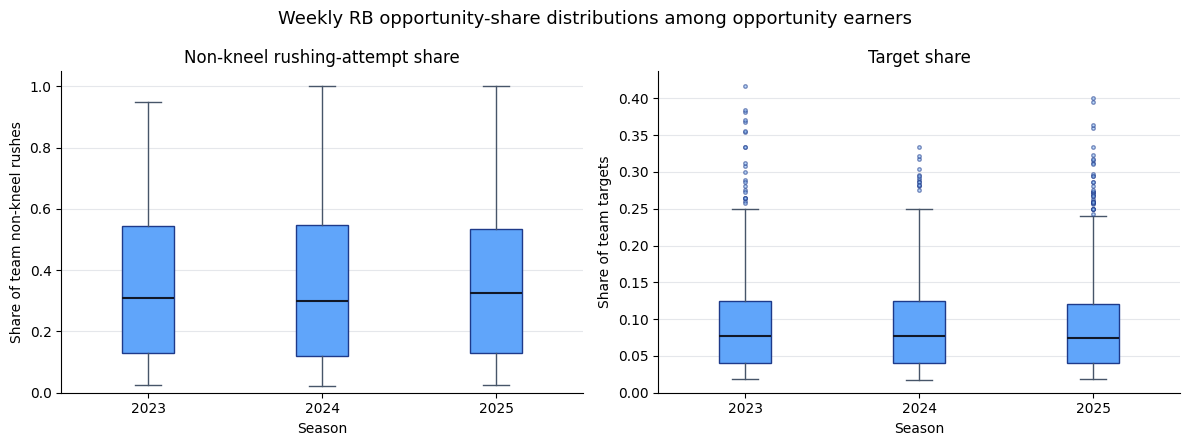

In [18]:
rush_share_population = silver_rb_week.loc[
    silver_rb_week["pbp_non_kneel_rush_attempts"].gt(0)
]
target_share_population = silver_rb_week.loc[silver_rb_week["pbp_targets"].gt(0)]
season_order = sorted(silver_rb_week["season"].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

rush_share_values = [
    rush_share_population.loc[
        rush_share_population["season"].eq(season), "rush_attempt_share"
    ].dropna().astype("float64")
    for season in season_order
]
target_share_values = [
    target_share_population.loc[
        target_share_population["season"].eq(season), "target_share"
    ].dropna().astype("float64")
    for season in season_order
]

box_style = {
    "patch_artist": True,
    "boxprops": {"facecolor": "#60a5fa", "edgecolor": "#1e3a8a"},
    "medianprops": {"color": "#111827", "linewidth": 1.5},
    "whiskerprops": {"color": "#475569"},
    "capprops": {"color": "#475569"},
    "flierprops": {
        "marker": "o",
        "markersize": 2.5,
        "markerfacecolor": "#93c5fd",
        "markeredgecolor": "#1e3a8a",
        "alpha": 0.55,
    },
}

axes[0].boxplot(rush_share_values, tick_labels=season_order, **box_style)
axes[0].set_title("Non-kneel rushing-attempt share")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Share of team non-kneel rushes")

axes[1].boxplot(target_share_values, tick_labels=season_order, **box_style)
axes[1].set_title("Target share")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Share of team targets")

for axis in axes:
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", color="#e5e7eb", linewidth=0.8)
    axis.grid(axis="x", visible=False)
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Weekly RB opportunity-share distributions among opportunity earners",
    fontsize=13,
)
fig.tight_layout()
plt.show()


Both panels use same-week team opportunity as the denominator. They describe how each type of work is distributed among participating RBs and FBs; they are not measures of efficiency or fantasy production.


### 16. Persist season-partitioned Silver Parquet

Each partition is written and immediately reloaded. Shape, columns, dtypes, season membership, and declared grain must survive the round trip.


In [19]:
RB_WEEK_DIR.mkdir(parents=True, exist_ok=True)

output_records = []
for season in SEASONS:
    rb_week_partition = (
        silver_rb_week.loc[silver_rb_week["season"].eq(season)]
        .sort_values(["week", "team", "player_id"])
        .reset_index(drop=True)
    )
    rb_week_path = RB_WEEK_DIR / f"rb_week_{season}.parquet"
    rb_week_partition.to_parquet(rb_week_path, index=False)
    rb_week_reloaded = pd.read_parquet(rb_week_path)

    assert rb_week_reloaded.shape == rb_week_partition.shape
    assert rb_week_reloaded.columns.tolist() == rb_week_partition.columns.tolist()
    assert (
        rb_week_reloaded.dtypes.astype(str).tolist()
        == rb_week_partition.dtypes.astype(str).tolist()
    )
    assert set(rb_week_reloaded["season"].unique()) == {season}
    assert not rb_week_reloaded.duplicated(RB_WEEK_GRAIN).any()

    output_records.append(
        {
            "dataset": "silver_rb_week",
            "season": season,
            "rows": len(rb_week_reloaded),
            "columns": len(rb_week_reloaded.columns),
            "grain": " + ".join(RB_WEEK_GRAIN),
            "duplicate_grain_rows": rb_week_reloaded.duplicated(RB_WEEK_GRAIN).sum(),
            "file_mb": rb_week_path.stat().st_size / 1024**2,
            "round_trip_passed": True,
        }
    )

output_summary = pd.DataFrame(output_records)

assert output_summary["rows"].sum() == len(silver_rb_week)
assert output_summary["duplicate_grain_rows"].eq(0).all()
assert output_summary["round_trip_passed"].all()

output_summary


,dataset,season,rows,columns,grain,duplicate_grain_rows,file_mb,round_trip_passed
0,silver_rb_week,2023,1938,62,player_id + season + week + team,0,0.120989,True
1,silver_rb_week,2024,1945,62,player_id + season + week + team,0,0.119575,True
2,silver_rb_week,2025,1943,62,player_id + season + week + team,0,0.120111,True


In [20]:
print(
    f"Wrote {len(output_summary):,} RB-week files with "
    f"{output_summary['rows'].sum():,} total rows, "
    f"{len(silver_rb_week.columns):,} columns, and "
    f"{output_summary['file_mb'].sum():.2f} MB on disk."
)


Wrote 3 RB-week files with 5,826 total rows, 62 columns, and 0.36 MB on disk.


## Takeaways

- `silver_rb_week` contains 5,826 contextual RB/FB player-weeks at `player_id + season + week + team`, with 1,938 rows in 2023, 1,945 in 2024, and 1,943 in 2025.
- Canonical PBP contributes 37,099 rush attempts and 9,692 targets. Target and receiving-air-yard totals reconcile exactly with weekly stats on all 5,084 stat rows.
- One documented source disagreement remains: Dare Ogunbowale has one official weekly-stat carry in 2024 Week 15, while the corresponding 35-yard play is labeled `no_play` and remains outside canonical PBP opportunity.
- The table preserves 742 snap-only RB/FB rows. Their weekly-stat fields remain null, while complete PBP coverage establishes zero rushing and receiving opportunity.
- Rushing shares distinguish non-kneel and designed team opportunities. Receiving shares reuse the validated WR definitions, and target share reproduces nflverse exactly.
- No RB/FB count exceeds its team denominator, and no same-week multi-team record violates the declared grain.
- Three 62-column season partitions pass schema, dtype, season, grain, and round-trip checks.
- The next position notebook can reuse the shared Silver foundation for QB facts while defining meaningful QB rushing, sacks, spikes, scrambles, and kneels explicitly.
